# Atividade de vendas no Brasil

In [5]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [6]:
df = pd.read_csv(r"../../data/vendas_brasil_1.csv")
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 37617 entries, 0 to 37616
Data columns (total 21 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   data_venda          37617 non-null  object 
 1   mes                 37617 non-null  int64  
 2   cidade              37617 non-null  object 
 3   canal_venda         37567 non-null  object 
 4   categoria           37617 non-null  object 
 5   produto             37617 non-null  object 
 6   vendedor            37577 non-null  object 
 7   fidelidade_cliente  37617 non-null  object 
 8   preco_unitario      37617 non-null  float64
 9   custo_unitario      37617 non-null  float64
 10  margem_pct          37535 non-null  float64
 11  quantidade          37617 non-null  int64  
 12  desconto_pct        37617 non-null  float64
 13  receita_total       37617 non-null  float64
 14  frete               35738 non-null  float64
 15  avaliacao_cliente   34662 non-null  float64
 16  praz

In [7]:
sum(df.duplicated())

1

Cada linha parece apresentar a venda de um tipo de produto, total: 37617.
As colunas contém informações sobre o produto ou sobre a venda.
Não identifiquei uma coluna de ID, apesar disso só há uma linha duplicada.
Talvez precisaríamos de mais meta dados para eliminar ambiguidades na interpretação das colunas para os cálculos que virão a seguir.

## Entregável 1 NumPy

### A. Criando arrays

In [8]:
preco_unitario = df['preco_unitario'].values
custo_unitario = df['custo_unitario'].values
quantidade = df['quantidade'].values
desconto_percentual = df['desconto_pct'].values
receita_total = df['receita_total'].values
frete = df['frete'].values

sum(type(array) != np.ndarray for array in [preco_unitario, custo_unitario, quantidade, desconto_percentual, receita_total, frete])

0

### B. Cálculos com operações vetorizadas

In [9]:
valor_bruto_venda = preco_unitario * quantidade
desconto_absoluto = desconto_percentual * valor_bruto_venda
custo_total = custo_unitario * quantidade
lucro = valor_bruto_venda - custo_total

Considerei o cálculo mais simples para o valor bruto da venda, mas a depender da regra de negócio e definição de valor bruto, poderíasse incluir o desconto ou frete

### C. Máscaras booleanas

In [10]:
media_receita = np.mean(receita_total)
df[df['receita_total'] > media_receita]

,data_venda,mes,cidade,canal_venda,categoria,produto,vendedor,fidelidade_cliente,preco_unitario,custo_unitario,...,quantidade,desconto_pct,receita_total,frete,avaliacao_cliente,prazo_entrega_dias,devolucao,entrega_no_prazo,alta_temporada,flag_outlier_preco
0,2022-04-13,4,Rio de Janeiro,App Mobile,Eletrônicos,Notebook,Bruno Souza,Diamante,739.39,561.75,...,10,5.2,6933.48,8.68,4.92,5.0,False,True,False,False
11,2022-11-27,11,São Paulo,Site Web,Esportes,Raquete,João Vieira,Prata,130.74,101.92,...,12,0.7,2167.48,6.80,4.52,14.0,False,False,True,False
15,2022-04-10,4,Salvador,Marketplace,Eletrônicos,Smartphone,Ana Lima,Bronze,1213.88,843.05,...,7,5.9,7945.96,47.18,3.52,12.0,False,False,False,True
17,2022-05-11,5,Belo Horizonte,App Mobile,Eletrônicos,Smartwatch,Elisa Costa,Prata,732.37,536.37,...,6,24.7,3314.59,48.72,2.94,4.0,False,True,False,False
20,2022-12-10,12,Recife,Site Web,Eletrônicos,Smartphone,Inês Nunes,Prata,603.40,394.18,...,14,5.9,11246.38,68.85,4.47,13.0,False,True,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
37593,2023-12-31,2,Manaus,Site Web,Eletrônicos,Tablet,Gabi Alves,Ouro,565.19,385.88,...,8,19.2,3636.00,77.13,4.02,17.0,False,False,False,False
37603,2023-12-31,9,Rio de Janeiro,App Mobile,Eletrônicos,Tablet,Inês Nunes,Prata,963.50,608.11,...,5,5.4,4554.52,18.19,3.49,3.0,False,True,False,True
37605,2023-12-31,3,Fortaleza,Marketplace,Esportes,Tapete de Yoga,Carla Mendes,Bronze,352.25,256.20,...,10,4.7,3369.62,42.94,3.52,7.0,False,True,False,False
37615,2023-12-31,11,São Paulo,Site Web,Esportes,Tapete de Yoga,João Vieira,Bronze,197.09,167.23,...,7,10.9,1960.18,30.99,3.50,6.0,False,True,True,False


9236 vendas de um total de 37617 tiveram receita acima da média
Poderíamos visualizar a distribuição das receitas através de gráficos

In [11]:
df[lucro < 0]

,data_venda,mes,cidade,canal_venda,categoria,produto,vendedor,fidelidade_cliente,preco_unitario,custo_unitario,...,quantidade,desconto_pct,receita_total,frete,avaliacao_cliente,prazo_entrega_dias,devolucao,entrega_no_prazo,alta_temporada,flag_outlier_preco


Sob as definições utilizadas, nenhuma venda deu prejuízo.

In [12]:
df[df['desconto_pct'] > 25]

,data_venda,mes,cidade,canal_venda,categoria,produto,vendedor,fidelidade_cliente,preco_unitario,custo_unitario,...,quantidade,desconto_pct,receita_total,frete,avaliacao_cliente,prazo_entrega_dias,devolucao,entrega_no_prazo,alta_temporada,flag_outlier_preco
24,2022-07-11,7,Recife,App Mobile,Vestuário,Jaqueta,Ana Lima,Bronze,186.43,151.02,...,14,25.4,1954.39,15.96,5.00,2.0,False,True,False,False
33,2022-02-28,2,Curitiba,Site Web,Vestuário,Calça Jeans,Diego Ferreira,Prata,148.35,92.37,...,14,25.2,1561.69,17.22,4.46,18.0,False,False,False,False
34,2023-05-26,5,Recife,Marketplace,Livros,Estatística Aplicada,Ana Lima,Prata,50.11,32.90,...,8,25.5,297.64,10.33,4.03,16.0,False,False,False,False
68,2022-01-02,1,Manaus,Marketplace,Vestuário,Tênis,Elisa Costa,Bronze,94.40,63.81,...,13,25.3,1328.46,10.83,3.98,16.0,True,False,True,False
76,2023-07-10,7,Salvador,Loja Física,Livros,Machine Learning,Inês Nunes,Bronze,99.36,80.05,...,7,25.4,518.23,12.31,5.00,4.0,True,True,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
37516,2023-12-31,1,Salvador,App Mobile,Alimentação,Whey Protein,Inês Nunes,Ouro,92.40,61.39,...,12,25.5,1197.94,4.56,4.98,14.0,False,True,True,False
37533,2023-12-31,5,Belo Horizonte,App Mobile,Alimentação,Granola,Henrique Dias,Prata,48.60,36.51,...,5,25.7,179.58,13.15,4.49,14.0,True,True,False,False
37576,2023-12-31,2,Porto Alegre,App Mobile,Livros,Cálculo Vol.1,Fábio Ramos,Ouro,53.69,34.35,...,3,25.4,120.45,10.82,4.01,9.0,False,False,False,False
37584,2023-12-31,1,Manaus,Loja Física,Alimentação,Azeite,Bruno Souza,Bronze,58.44,46.95,...,13,25.8,772.56,9.29,4.53,9.0,False,False,True,False


2304 vendas de um total de 37617 tiveram desconto acima de 25%

### D. Agregações

In [13]:
media_receita = np.mean(receita_total)
maximo_receita = np.max(receita_total)
minimo_receita = np.min(receita_total)
media_lucro = np.mean(lucro)
qtd_vendas_prejuizo = df[lucro < 0].shape[0]

print(f'Média da receita: {media_receita:.2f}')
print(f'Máximo da receita: {maximo_receita:.2f}')
print(f'Mínimo da receita: {minimo_receita:.2f}')
print(f'Média do lucro: {media_lucro:.2f}')
print(f'Quantidade de vendas em prejuízo: {qtd_vendas_prejuizo}')

Média da receita: 1891.69
Máximo da receita: 58430.28
Mínimo da receita: 3.70
Média do lucro: 522.40
Quantidade de vendas em prejuízo: 0


De forma geral, as vendas têm receita concentrada perto da média, sem nenhum caso de prejuízo sob as definições usadas, e cerca de 6% dos pedidos com desconto acima de 25%.

## Entregável 2 Pandas

### A. Primeiro olhar no dataset

In [14]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 37617 entries, 0 to 37616
Data columns (total 21 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   data_venda          37617 non-null  object 
 1   mes                 37617 non-null  int64  
 2   cidade              37617 non-null  object 
 3   canal_venda         37567 non-null  object 
 4   categoria           37617 non-null  object 
 5   produto             37617 non-null  object 
 6   vendedor            37577 non-null  object 
 7   fidelidade_cliente  37617 non-null  object 
 8   preco_unitario      37617 non-null  float64
 9   custo_unitario      37617 non-null  float64
 10  margem_pct          37535 non-null  float64
 11  quantidade          37617 non-null  int64  
 12  desconto_pct        37617 non-null  float64
 13  receita_total       37617 non-null  float64
 14  frete               35738 non-null  float64
 15  avaliacao_cliente   34662 non-null  float64
 16  praz

In [15]:
df.isnull().sum()

data_venda               0
mes                      0
cidade                   0
canal_venda             50
categoria                0
produto                  0
vendedor                40
fidelidade_cliente       0
preco_unitario           0
custo_unitario           0
margem_pct              82
quantidade               0
desconto_pct             0
receita_total            0
frete                 1879
avaliacao_cliente     2955
prazo_entrega_dias    1504
devolucao                0
entrega_no_prazo         0
alta_temporada           0
flag_outlier_preco       0
dtype: int64

O dataframe apresenta 37617 linhas, 21 colunas.
As colunas canal_venda, vendedor, margem_pct, frete, avaliacao_cliente, prazo_entrega_dias apresentam valores faltantes


In [16]:
#Colunas numéricas
colunas_numericas = df.select_dtypes(include=["int64", "float64"]).columns.tolist()

#Colunas categóricas
colunas_categoricas = df.select_dtypes(include=["object", "bool"]).columns.tolist()

print("Colunas numéricas:", colunas_numericas)
print("Colunas categóricas:", colunas_categoricas)

Colunas numéricas: ['mes', 'preco_unitario', 'custo_unitario', 'margem_pct', 'quantidade', 'desconto_pct', 'receita_total', 'frete', 'avaliacao_cliente', 'prazo_entrega_dias']
Colunas categóricas: ['data_venda', 'cidade', 'canal_venda', 'categoria', 'produto', 'vendedor', 'fidelidade_cliente', 'devolucao', 'entrega_no_prazo', 'alta_temporada', 'flag_outlier_preco']


As colunas numéricas incluem preços, custos, quantidade, desconto e receita; as categóricas incluem cidade, canal de venda, produto e vendedor, entre outras.

### B. Limpeza e tratamento

In [17]:
#Conversão da coluna de data para datetime
df['data_venda'] = pd.to_datetime(df['data_venda'], format='mixed')

In [18]:
#Padronização coluna categórica
df['cidade'] = df['cidade'].str.lower().str.strip()
df['canal_venda'] = df['canal_venda'].str.strip().str.lower()

mapa_cidades = {
    "curtiba": "curitiba",
    "sp": "são paulo",
    "s. paulo": "são paulo",
    "sao paulo": "são paulo",
    "rj": "rio de janeiro",
    "rio": "rio de janeiro",
    "bh": "belo horizonte",
    "b. horizonte": "belo horizonte",
    "slavador": "salvador"
}
mapa_canal = {
    'siteweb': 'site web',
    'loja fisica': 'loja física',
}

df["cidade"] = df["cidade"].map(lambda x: mapa_cidades.get(x, x))
df["canal_venda"] = df["canal_venda"].map(lambda x: mapa_canal.get(x, x))

print("Cidades únicas:", df['cidade'].unique())
print("Canais de venda únicos:", df['canal_venda'].unique())

Cidades únicas: ['rio de janeiro' 'manaus' 'goiânia' 'fortaleza' 'belo horizonte' 'recife'
 'são paulo' 'porto alegre' 'salvador' 'curitiba']
Canais de venda únicos: ['app mobile' 'site web' 'loja física' 'marketplace' 'televendas' nan]


In [19]:
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor

features_canal = ['cidade', 'categoria', 'produto', 'fidelidade_cliente',
                   'preco_unitario', 'quantidade', 'desconto_pct']

X = pd.get_dummies(df[features_canal], drop_first=True)
y = df['canal_venda']

y_treino = y.notna()
y_faltante = y.isna()

modelo_canal = RandomForestClassifier(n_estimators=200, random_state=42)
modelo_canal.fit(X[y_treino], y[y_treino])

df.loc[y_faltante, 'canal_venda'] = modelo_canal.predict(X[y_faltante])

In [20]:
features_frete = ['cidade', 'categoria', 'produto', 'preco_unitario',
                   'quantidade', 'canal_venda']

X = pd.get_dummies(df[features_frete], drop_first=True)
y = df['frete']

y_treino = y.notna()
y_faltante = y.isna()

modelo_frete = RandomForestRegressor(n_estimators=200, random_state=42)
modelo_frete.fit(X[y_treino], y[y_treino])

df.loc[y_faltante, 'frete'] = modelo_frete.predict(X[y_faltante])

In [21]:
df[['canal_venda', 'frete']].isnull().sum()

canal_venda    0
frete          0
dtype: int64

Para canal_venda e frete, optei por um modelo preditivo (RandomForest) em vez de média/moda, já que essas colunas têm relação com outras variáveis do dataset (cidade, categoria, preço) e gostaríamos de inputar o valor mais provavél dada essas covariáveis. As demais colunas com faltantes (vendedor, margem_pct, avaliacao_cliente, prazo_entrega_dias) não foram tratadas nesta etapa.

### C. Criação de novas colunas

In [35]:
df['ano'] = df['data_venda'].dt.year
df['fim_de_semana'] = df['data_venda'].apply(lambda x: x.weekday() >= 5)
df['faixa_preco'] = df['preco_unitario'].apply(lambda x: 'Baixo' if x < 100 else 'Médio' if x < 500 else 'Alto')


### D. Filtros

In [36]:
#1. Quais vendas tiveram receita acima de determinado valor?
Q1 = df["receita_total"].quantile(0.25)
Q3 = df["receita_total"].quantile(0.75)
IQR = Q3 - Q1

limite_superior = Q3 + 1.5 * IQR

outliers_upper = df[df["receita_total"] > limite_superior]

outliers_upper

,data_venda,mes,cidade,canal_venda,categoria,produto,vendedor,fidelidade_cliente,preco_unitario,custo_unitario,...,prazo_entrega_dias,devolucao,entrega_no_prazo,alta_temporada,flag_outlier_preco,ano,dia_de_semana,faixa_preco,regiao,fim_de_semana
0,2022-04-13,4,rio de janeiro,app mobile,Eletrônicos,Notebook,Bruno Souza,Diamante,739.39,561.75,...,5.0,False,True,False,False,2022,False,Alto,Sudeste,False
15,2022-04-10,4,salvador,marketplace,Eletrônicos,Smartphone,Ana Lima,Bronze,1213.88,843.05,...,12.0,False,False,False,True,2022,True,Alto,Nordeste,True
20,2022-12-10,12,recife,site web,Eletrônicos,Smartphone,Inês Nunes,Prata,603.40,394.18,...,13.0,False,True,True,False,2022,True,Alto,Nordeste,True
21,2023-05-07,5,são paulo,loja física,Eletrônicos,Smartwatch,Gabi Alves,Bronze,892.83,660.58,...,18.0,True,True,False,True,2023,True,Alto,Sudeste,True
23,2023-01-21,1,manaus,site web,Esportes,Bicicleta,Carla Mendes,Bronze,257.83,207.71,...,13.0,False,True,True,False,2023,True,Médio,Norte,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
37566,2023-12-31,12,salvador,loja física,Eletrônicos,Tablet,Inês Nunes,Prata,1383.40,878.95,...,NaN,False,False,True,True,2023,True,Alto,Nordeste,True
37574,2023-12-31,9,rio de janeiro,site web,Eletrônicos,Smartwatch,Elisa Costa,Ouro,739.62,507.93,...,12.0,False,True,False,False,2023,True,Alto,Sudeste,True
37578,2023-12-31,10,manaus,loja física,Eletrônicos,Smartwatch,Gabi Alves,Bronze,1086.24,817.87,...,4.0,False,True,False,True,2023,True,Alto,Norte,True
37583,2023-12-31,2,manaus,loja física,Eletrônicos,Smartwatch,Henrique Dias,Bronze,846.16,697.37,...,10.0,True,True,False,True,2023,True,Alto,Norte,True


In [24]:
#2. Quais vendas tiveram devolução?
devolucoes = df[df['devolucao'] == 1]

devolucoes

,data_venda,mes,cidade,canal_venda,categoria,produto,vendedor,fidelidade_cliente,preco_unitario,custo_unitario,...,frete,avaliacao_cliente,prazo_entrega_dias,devolucao,entrega_no_prazo,alta_temporada,flag_outlier_preco,ano,dia_de_semana,faixa_preco
1,2023-03-12,3,manaus,site web,Vestuário,Camiseta,Elisa Costa,Bronze,187.48,135.15,...,29.75435,4.98,19.0,True,False,False,False,2023,True,Médio
2,2022-09-28,9,goiânia,app mobile,Vestuário,Tênis,João Vieira,Bronze,76.11,61.40,...,7.98000,3.47,NaN,True,True,False,False,2022,False,Baixo
7,2023-09-07,9,manaus,app mobile,Alimentação,Mel Orgânico,Inês Nunes,Prata,35.72,21.62,...,24.98000,3.03,18.0,True,False,False,False,2023,False,Baixo
18,2023-10-24,10,manaus,site web,Vestuário,Camiseta,Carla Mendes,Prata,65.73,41.26,...,56.61000,NaN,16.0,True,True,False,False,2023,False,Baixo
21,2023-05-07,5,são paulo,loja física,Eletrônicos,Smartwatch,Gabi Alves,Bronze,892.83,660.58,...,9.89000,1.05,18.0,True,True,False,True,2023,True,Alto
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
37522,2023-12-31,11,salvador,marketplace,Esportes,Bicicleta,Carla Mendes,Bronze,195.87,161.39,...,6.95000,2.95,7.0,True,True,True,False,2023,True,Médio
37525,2023-12-31,11,curitiba,loja física,Esportes,Luva de Box,Ana Lima,Prata,248.42,183.21,...,8.57000,2.04,13.0,True,True,True,False,2023,True,Médio
37533,2023-12-31,5,belo horizonte,app mobile,Alimentação,Granola,Henrique Dias,Prata,48.60,36.51,...,13.15000,4.49,14.0,True,True,False,False,2023,True,Baixo
37583,2023-12-31,2,manaus,loja física,Eletrônicos,Smartwatch,Henrique Dias,Bronze,846.16,697.37,...,14.03000,1.00,10.0,True,True,False,True,2023,True,Alto


In [25]:
#3. Quais vendas pertencem a uma categoria específica?
print(df['categoria'].value_counts())

eletronicos = df[df['categoria'] == 'Eletrônicos']

eletronicos

categoria
Esportes       7646
Vestuário      7578
Eletrônicos    7515
Alimentação    7472
Livros         7406
Name: count, dtype: int64


,data_venda,mes,cidade,canal_venda,categoria,produto,vendedor,fidelidade_cliente,preco_unitario,custo_unitario,...,frete,avaliacao_cliente,prazo_entrega_dias,devolucao,entrega_no_prazo,alta_temporada,flag_outlier_preco,ano,dia_de_semana,faixa_preco
0,2022-04-13,4,rio de janeiro,app mobile,Eletrônicos,Notebook,Bruno Souza,Diamante,739.39,561.75,...,8.68,4.92,5.0,False,True,False,False,2022,False,Alto
15,2022-04-10,4,salvador,marketplace,Eletrônicos,Smartphone,Ana Lima,Bronze,1213.88,843.05,...,47.18,3.52,12.0,False,False,False,True,2022,True,Alto
17,2022-05-11,5,belo horizonte,app mobile,Eletrônicos,Smartwatch,Elisa Costa,Prata,732.37,536.37,...,48.72,2.94,4.0,False,True,False,False,2022,False,Alto
20,2022-12-10,12,recife,site web,Eletrônicos,Smartphone,Inês Nunes,Prata,603.40,394.18,...,68.85,4.47,13.0,False,True,True,False,2022,True,Alto
21,2023-05-07,5,são paulo,loja física,Eletrônicos,Smartwatch,Gabi Alves,Bronze,892.83,660.58,...,9.89,1.05,18.0,True,True,False,True,2023,True,Alto
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
37589,2023-12-31,4,rio de janeiro,app mobile,Eletrônicos,Fone Bluetooth,Fábio Ramos,Bronze,899.09,734.88,...,20.08,4.04,8.0,True,False,False,True,2023,True,Alto
37593,2023-12-31,2,manaus,site web,Eletrônicos,Tablet,Gabi Alves,Ouro,565.19,385.88,...,77.13,4.02,17.0,False,False,False,False,2023,True,Alto
37600,2023-12-31,12,fortaleza,app mobile,Eletrônicos,Tablet,Henrique Dias,Ouro,212.67,167.18,...,7.09,2.05,6.0,False,True,True,False,2023,True,Médio
37603,2023-12-31,9,rio de janeiro,app mobile,Eletrônicos,Tablet,Inês Nunes,Prata,963.50,608.11,...,18.19,3.49,3.0,False,True,False,True,2023,True,Alto


In [37]:
print("Quantidade de outliers:", outliers_upper.shape[0], ",", round(outliers_upper.shape[0]/df.shape[0]*100, 2), "%")
print("Quantidade de devoluções:", devolucoes.shape[0], ",", round(devolucoes.shape[0]/df.shape[0]*100, 2), "%")
print("Quantidade de vendas de eletrônicos:", eletronicos.shape[0], ",", round(eletronicos.shape[0]/df.shape[0]*100, 2), "%")
print("Quantidade total de vendas:", df.shape[0], ",", round(df.shape[0]/df.shape[0]*100, 2), "%")

Quantidade de outliers: 4803 , 12.77 %
Quantidade de devoluções: 3532 , 9.39 %
Quantidade de vendas de eletrônicos: 7515 , 19.98 %
Quantidade total de vendas: 37617 , 100.0 %


Encontramos 4803 valores discrepantes de um total de 37617
9,39% dos pedidos tiveram devolução
19,98% dos pedidos são da categoria de eletrônicos

### E. Agrupamentos com groupby

In [27]:
# 1. Categoria com maior receita total
df.groupby('categoria')['receita_total'].sum().sort_values(ascending=False)


categoria
Eletrônicos    45017479.88
Esportes       11567480.75
Vestuário       6780473.93
Livros          4462597.93
Alimentação     3331601.51
Name: receita_total, dtype: float64

In [28]:
# 2. Canal de venda com maior quantidade de vendas (contagem de linhas/vendas)
df.groupby('canal_venda').size().sort_values(ascending=False)

canal_venda
site web       11371
app mobile     11269
loja física     7507
marketplace     5609
televendas      1861
dtype: int64

In [29]:
# 3. Cidade com maior receita
df.groupby('cidade')['receita_total'].sum().sort_values(ascending=False)

cidade
recife            7662241.79
manaus            7459161.23
fortaleza         7242081.82
goiânia           7178113.69
porto alegre      7048428.17
curitiba          6993175.07
salvador          6918656.01
belo horizonte    6914747.61
rio de janeiro    6880176.34
são paulo         6862852.27
Name: receita_total, dtype: float64

A categoria com maior receita total é a de eletrônicos
O maior canal de vendas é pelo site web
A cidade com maior receita foi a de Recife

### F. Merge

In [30]:
regioes = pd.DataFrame({
    "cidade": [
        "rio de janeiro",
        "são paulo",
        "belo horizonte",
        "curitiba",
        "porto alegre",
        "salvador",
        "fortaleza",
        "recife",
        "manaus",
        "goiânia"
    ],
    "regiao": [
        "Sudeste",
        "Sudeste",
        "Sudeste",
        "Sul",
        "Sul",
        "Nordeste",
        "Nordeste",
        "Nordeste",
        "Norte",
        "Centro-Oeste"
    ]
})

df = df.merge(regioes, on="cidade", how="left")

df['regiao'].value_counts()

regiao
Nordeste        11366
Sudeste         11098
Sul              7564
Norte            3804
Centro-Oeste     3785
Name: count, dtype: int64

O Nordeste e o Sudeste concentram a maior parte da receita, puxados por Recife e pela categoria Eletrônicos. O site web é o canal predominante, e cerca de 9,4% dos pedidos têm devolução.

## Entregável 3 Seaborn

### A. Gráfico de barras

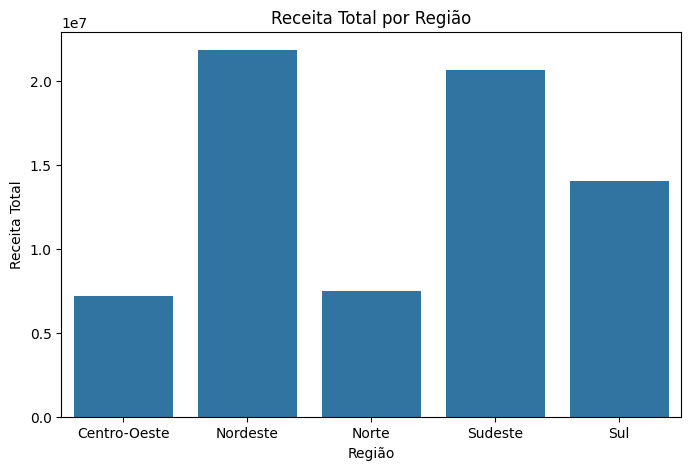

In [31]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=df.groupby("regiao")["receita_total"].sum().reset_index(),
    x="regiao",
    y="receita_total"
)

plt.title("Receita Total por Região")
plt.xlabel("Região")
plt.ylabel("Receita Total")
plt.show()

Nordeste e Sudeste têm receita bem acima das demais regiões, enquanto Norte e Centro-Oeste ficam próximos entre si e bem abaixo, reflexo de terem só uma cidade cada uma na tabela de regiões.

### B. Gráfico de linha

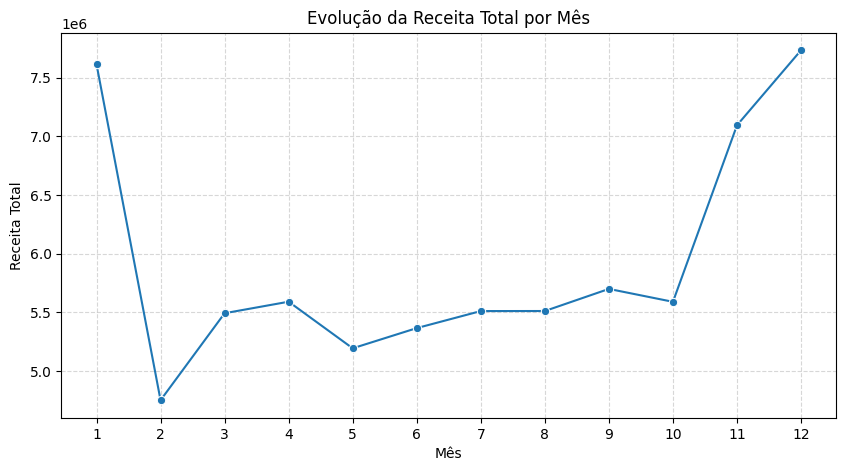

In [32]:
receita_mes = (
    df.groupby("mes", as_index=False)["receita_total"]
      .sum()
      .sort_values("mes")
)

plt.figure(figsize=(10, 5))
sns.lineplot(
    data=receita_mes,
    x="mes",
    y="receita_total",
    marker="o"
)

plt.title("Evolução da Receita Total por Mês")
plt.xlabel("Mês")
plt.ylabel("Receita Total")
plt.xticks(range(1, 13))
plt.grid(True, linestyle="--", alpha=0.5)
plt.show()

A receita mensal oscila ao longo do ano sem uma tendência de crescimento ou queda muito clara, mas há um pico visível perto nos meses de novembro, dezembro e janeiro, possivelmente ligado à alta temporada.

### C. Gráfico de dispersão

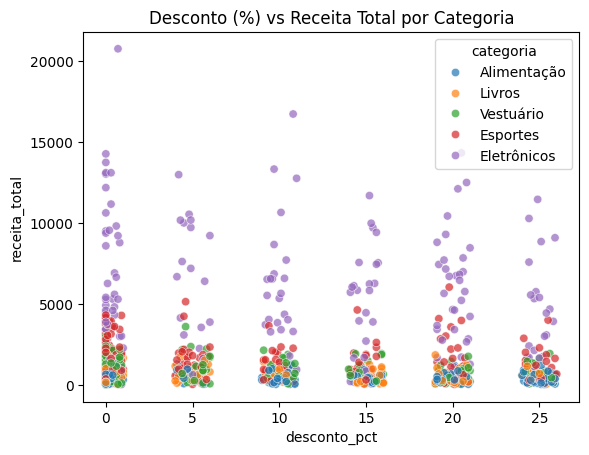

In [39]:
amostra = df.sample(n=1000, random_state=42)

sns.scatterplot(
    data=amostra,
    x="desconto_pct",
    y="receita_total",
    hue="categoria",
    alpha=0.7
)
plt.title("Desconto (%) vs Receita Total por Categoria")
plt.show()

Não há uma relação linear clara entre desconto e receita; os pontos formam faixas separadas por categoria, indicando que a receita é mais influenciada pelo preço do produto do que pelo desconto aplicado.

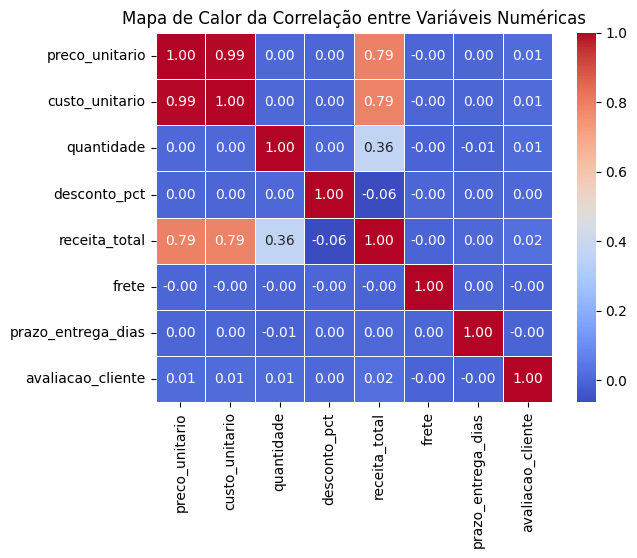

In [34]:
colunas = [
    "preco_unitario",
    "custo_unitario",
    "quantidade",
    "desconto_pct",
    "receita_total",
    "frete",
    "prazo_entrega_dias",
    "avaliacao_cliente"
]

correlacao = df[colunas].corr()

sns.heatmap(
    correlacao,
    annot=True,      
    cmap="coolwarm", 
    fmt=".2f",
    linewidths=0.5
)

plt.title("Mapa de Calor da Correlação entre Variáveis Numéricas")
plt.show()

Preço unitário, custo unitário e receita total são fortemente correlacionados entre si, como esperado. As demais variáveis (desconto, frete, prazo de entrega, avaliação do cliente) têm correlação próxima de zero com as outras, sugerindo que não seguem uma relação linear direta com receita ou preço.

Os gráficos reforçam os achados anteriores: receita concentrada em Eletrônicos e nas regiões Nordeste/Sudeste, sazonalidade leve ao longo do ano, e pouca relação linear entre desconto/frete/prazo e a receita, o que indica que outros fatores (como preço e categoria) pesam mais no resultado final da venda.